# Part 5 Task: Kdrama Wikipedia Pageviews

For this task, I am looking at patterns in interest in Kdramas using Wikipedia pageviews. My goal is to recreate Graph 1 and Graph 2 from the assignment.

## Table of Contents

1. [Plan](#plan)
2. [Load the Kdrama Data](#load-data)
3. [Choose the Dramas](#choose-dramas)
4. [Get Wikipedia Pageviews](#pageviews)
5. [Graph 1: Total Pageviews](#graph-1)
6. [Prepare Data for Graph 2](#prepare-graph-2)
7. [Graph 2: Pageviews Around the Peak](#graph-2)
8. [What I Notice](#reflection)

<a id="plan"></a>
## Plan

1. Load the 2023 Kdrama CSV using pandas.
2. Figure out which dramas are used in the graphs.
3. Get the Wikipedia pageviews for each drama.
4. Add up the total pageviews for each drama.
5. Sort the dramas from most pageviews to least.
6. Make a horizontal bar chart for Graph 1.
7. For Graph 2, find the day each drama had the most pageviews.
8. Compare the days before and after that peak day.
9. Plot the pageviews with the peak day as Day 0.
10. Use fill_between to shade under the lines.

<a id="load-data"></a>

## Load the Kdrama Data

First, I loaded the MyDramaList data for Kdramas released in 2023.

In [2]:
import pandas as pd

df = pd.read_csv('kdramas_2023.csv')

df.head()
df.shape
df.columns
df['Title_English'].head(20)

0                               High Cookie (2023)
1                           Strangers Again (2023)
2                  Hello! This Is Starbucks (2023)
3                                Adult Kids (2023)
4                                  My Demon (2023)
5                           The Matchmakers (2023)
6                             D.P. Season 2 (2023)
7                           Longing for You (2023)
8                                    Intern (2023)
9                                  Why R U? (2023)
10                                   Doona! (2023)
11                         Love to Hate You (2023)
12                  Couple Scandal Season 2 (2023)
13                                     Race (2023)
14                                  Boyhood (2023)
15                    Divorce Attorney Shin (2023)
16        Those Who Pass Through Gimpo City (2023)
17    The Story of Park's Marriage Contract (2023)
18                        Youth on the Road (2023)
19                             

<a id="choose-dramas"></a>

## Choose the Dramas

The assignment graphs use a smaller group of dramas from the full 2023 dataset. I made a list of the Wikipedia page titles for those dramas.

In [3]:
dramas = [
    "The Glory (TV series)",
    "Moving (South Korean TV series)",
    "My Demon",
    "King the Land",
    "Gyeongseong Creature",
    "Twinkling Watermelon",
    "Death's Game",
    "Crash Course in Romance",
    "Welcome to Samdal-ri",
    "Celebrity (South Korean TV series)",
    "A Time Called You",
    "Perfect Marriage Revenge",
    "See You in My 19th Life",
    "The Good Bad Mother",
    "My Lovely Liar",
    "Doona!",
    "Love to Hate You (TV series)",
    "Daily Dose of Sunshine",
    "Destined with You"
]

<a id="pageviews"></a>

## Get Wikipedia Pageviews

I used the `mwviews` library from the Friday Wikipedia tutorial to get daily Wikipedia pageviews for each drama.

In [4]:
from mwviews.api import PageviewsClient

p = PageviewsClient(user_agent="CS315 Student")

In [6]:
test = p.article_views(
    'en.wikipedia',
    ['My Demon'],
    start='20220601',
    end='20240601'
)

list(test.items())[:3]

[(datetime.datetime(2022, 6, 1, 0, 0), {'My_Demon': None}),
 (datetime.datetime(2022, 6, 2, 0, 0), {'My_Demon': None}),
 (datetime.datetime(2022, 6, 3, 0, 0), {'My_Demon': None})]

In [7]:
pageviews = {}

for drama in dramas:
    print("Getting:", drama)

    data = p.article_views(
        'en.wikipedia',
        [drama],
        start='20220601',
        end='20240601'
    )

    pageviews[drama] = data

Getting: The Glory (TV series)
Getting: Moving (South Korean TV series)
Getting: My Demon
Getting: King the Land
Getting: Gyeongseong Creature
Getting: Twinkling Watermelon
Getting: Death's Game
Getting: Crash Course in Romance
Getting: Welcome to Samdal-ri
Getting: Celebrity (South Korean TV series)
Getting: A Time Called You
Getting: Perfect Marriage Revenge
Getting: See You in My 19th Life
Getting: The Good Bad Mother
Getting: My Lovely Liar
Getting: Doona!
Getting: Love to Hate You (TV series)
Getting: Daily Dose of Sunshine
Getting: Destined with You


In [8]:
list(pageviews.items())[:3]

[('The Glory (TV series)',
  defaultdict(dict,
              {datetime.datetime(2022, 6, 1, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 2, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 3, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 4, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 5, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 6, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 7, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 8, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 9, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 10, 0, 0): {'The_Glory_(TV_series)': None},
               datetime.datetime(2022, 6, 11, 0, 0): {'The_Glory_(TV_series)': None},
               d

<a id="graph-1"></a>

## Graph 1: Total Pageviews

For the first graph, I need the total number of Wikipedia pageviews for each drama during the full time period.

In [9]:
totals = {}

for drama in dramas:
    totals[drama] = 0

for date in pageviews:
    for drama in dramas:
        views = pageviews[date].get(drama)

        if views != None:
            totals[drama] = totals[drama] + views
totals

{'The Glory (TV series)': 0,
 'Moving (South Korean TV series)': 0,
 'My Demon': 0,
 'King the Land': 0,
 'Gyeongseong Creature': 0,
 'Twinkling Watermelon': 0,
 "Death's Game": 0,
 'Crash Course in Romance': 0,
 'Welcome to Samdal-ri': 0,
 'Celebrity (South Korean TV series)': 0,
 'A Time Called You': 0,
 'Perfect Marriage Revenge': 0,
 'See You in My 19th Life': 0,
 'The Good Bad Mother': 0,
 'My Lovely Liar': 0,
 'Doona!': 0,
 'Love to Hate You (TV series)': 0,
 'Daily Dose of Sunshine': 0,
 'Destined with You': 0}

In [10]:
total_df = pd.DataFrame(
    list(totals.items()),
    columns=['Drama', 'Pageviews']
)

total_df.head()

total_df = total_df.sort_values(
    'Pageviews',
    ascending=False
)

total_df

,Drama,Pageviews
0,The Glory (TV series),0
1,Moving (South Korean TV series),0
2,My Demon,0
3,King the Land,0
4,Gyeongseong Creature,0
5,Twinkling Watermelon,0
6,Death's Game,0
7,Crash Course in Romance,0
8,Welcome to Samdal-ri,0
9,Celebrity (South Korean TV series),0


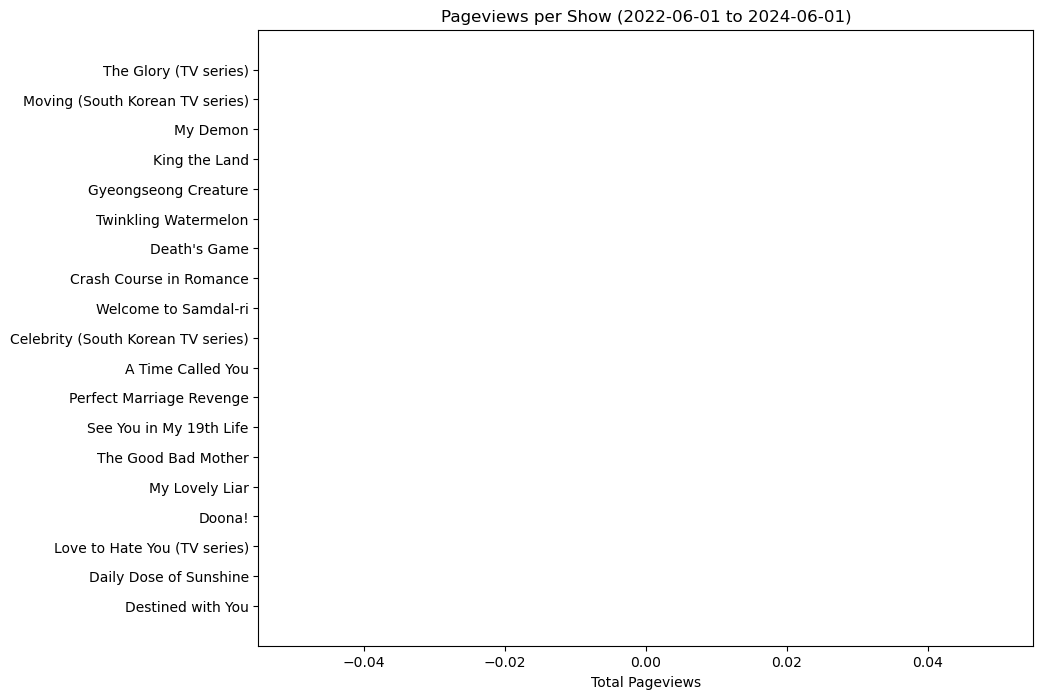

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.barh(
    total_df['Drama'],
    total_df['Pageviews']
)

plt.xlabel('Total Pageviews')
plt.title('Pageviews per Show (2022-06-01 to 2024-06-01)')

plt.gca().invert_yaxis()

plt.show()

<a id="prepare-graph-2"></a>

## Prepare Data for Graph 2

For Graph 2, the dramas need to be lined up based on their peak pageview date. The day with the most pageviews for each drama becomes Day 0. Days before the peak will be negative and days after the peak will be positive.

In [12]:
pageviews_df = pd.DataFrame.from_dict(
    pageviews,
    orient='index'
)

pageviews_df.head()

,2022-06-01,2022-06-02,2022-06-03,2022-06-04,2022-06-05,2022-06-06,2022-06-07,2022-06-08,2022-06-09,2022-06-10,...,2024-05-23,2024-05-24,2024-05-25,2024-05-26,2024-05-27,2024-05-28,2024-05-29,2024-05-30,2024-05-31,2024-06-01
The Glory (TV series),{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},...,{'The_Glory_(TV_series)': 2493},{'The_Glory_(TV_series)': 2680},{'The_Glory_(TV_series)': 2699},{'The_Glory_(TV_series)': 2951},{'The_Glory_(TV_series)': 2878},{'The_Glory_(TV_series)': 2761},{'The_Glory_(TV_series)': 2638},{'The_Glory_(TV_series)': 2500},{'The_Glory_(TV_series)': 2608},{'The_Glory_(TV_series)': 2614}
Moving (South Korean TV series),{'Moving_(South_Korean_TV_series)': 199},{'Moving_(South_Korean_TV_series)': 176},{'Moving_(South_Korean_TV_series)': 183},{'Moving_(South_Korean_TV_series)': 167},{'Moving_(South_Korean_TV_series)': 212},{'Moving_(South_Korean_TV_series)': 166},{'Moving_(South_Korean_TV_series)': 187},{'Moving_(South_Korean_TV_series)': 205},{'Moving_(South_Korean_TV_series)': 197},{'Moving_(South_Korean_TV_series)': 159},...,{'Moving_(South_Korean_TV_series)': 1424},{'Moving_(South_Korean_TV_series)': 1314},{'Moving_(South_Korean_TV_series)': 1441},{'Moving_(South_Korean_TV_series)': 1858},{'Moving_(South_Korean_TV_series)': 1643},{'Moving_(South_Korean_TV_series)': 1756},{'Moving_(South_Korean_TV_series)': 1551},{'Moving_(South_Korean_TV_series)': 1656},{'Moving_(South_Korean_TV_series)': 1866},{'Moving_(South_Korean_TV_series)': 1778}
My Demon,{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},...,{'My_Demon': 1632},{'My_Demon': 1615},{'My_Demon': 1631},{'My_Demon': 1782},{'My_Demon': 1676},{'My_Demon': 1620},{'My_Demon': 1566},{'My_Demon': 1480},{'My_Demon': 1572},{'My_Demon': 1715}
King the Land,{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},...,{'King_the_Land': 995},{'King_the_Land': 1004},{'King_the_Land': 1026},{'King_the_Land': 1250},{'King_the_Land': 1255},{'King_the_Land': 1195},{'King_the_Land': 1129},{'King_the_Land': 1182},{'King_the_Land': 1064},{'King_the_Land': 1049}
Gyeongseong Creature,{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},...,{'Gyeongseong_Creature': 1184},{'Gyeongseong_Creature': 1219},{'Gyeongseong_Creature': 1338},{'Gyeongseong_Creature': 1408},{'Gyeongseong_Creature': 1304},{'Gyeongseong_Creature': 1261},{'Gyeongseong_Creature': 1210},{'Gyeongseong_Creature': 1369},{'Gyeongseong_Creature': 1363},{'Gyeongseong_Creature': 1399}


In [14]:
pageviews_df.head()

,2022-06-01,2022-06-02,2022-06-03,2022-06-04,2022-06-05,2022-06-06,2022-06-07,2022-06-08,2022-06-09,2022-06-10,...,2024-05-23,2024-05-24,2024-05-25,2024-05-26,2024-05-27,2024-05-28,2024-05-29,2024-05-30,2024-05-31,2024-06-01
The Glory (TV series),{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},{'The_Glory_(TV_series)': None},...,{'The_Glory_(TV_series)': 2493},{'The_Glory_(TV_series)': 2680},{'The_Glory_(TV_series)': 2699},{'The_Glory_(TV_series)': 2951},{'The_Glory_(TV_series)': 2878},{'The_Glory_(TV_series)': 2761},{'The_Glory_(TV_series)': 2638},{'The_Glory_(TV_series)': 2500},{'The_Glory_(TV_series)': 2608},{'The_Glory_(TV_series)': 2614}
Moving (South Korean TV series),{'Moving_(South_Korean_TV_series)': 199},{'Moving_(South_Korean_TV_series)': 176},{'Moving_(South_Korean_TV_series)': 183},{'Moving_(South_Korean_TV_series)': 167},{'Moving_(South_Korean_TV_series)': 212},{'Moving_(South_Korean_TV_series)': 166},{'Moving_(South_Korean_TV_series)': 187},{'Moving_(South_Korean_TV_series)': 205},{'Moving_(South_Korean_TV_series)': 197},{'Moving_(South_Korean_TV_series)': 159},...,{'Moving_(South_Korean_TV_series)': 1424},{'Moving_(South_Korean_TV_series)': 1314},{'Moving_(South_Korean_TV_series)': 1441},{'Moving_(South_Korean_TV_series)': 1858},{'Moving_(South_Korean_TV_series)': 1643},{'Moving_(South_Korean_TV_series)': 1756},{'Moving_(South_Korean_TV_series)': 1551},{'Moving_(South_Korean_TV_series)': 1656},{'Moving_(South_Korean_TV_series)': 1866},{'Moving_(South_Korean_TV_series)': 1778}
My Demon,{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},{'My_Demon': None},...,{'My_Demon': 1632},{'My_Demon': 1615},{'My_Demon': 1631},{'My_Demon': 1782},{'My_Demon': 1676},{'My_Demon': 1620},{'My_Demon': 1566},{'My_Demon': 1480},{'My_Demon': 1572},{'My_Demon': 1715}
King the Land,{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},{'King_the_Land': None},...,{'King_the_Land': 995},{'King_the_Land': 1004},{'King_the_Land': 1026},{'King_the_Land': 1250},{'King_the_Land': 1255},{'King_the_Land': 1195},{'King_the_Land': 1129},{'King_the_Land': 1182},{'King_the_Land': 1064},{'King_the_Land': 1049}
Gyeongseong Creature,{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},{'Gyeongseong_Creature': None},...,{'Gyeongseong_Creature': 1184},{'Gyeongseong_Creature': 1219},{'Gyeongseong_Creature': 1338},{'Gyeongseong_Creature': 1408},{'Gyeongseong_Creature': 1304},{'Gyeongseong_Creature': 1261},{'Gyeongseong_Creature': 1210},{'Gyeongseong_Creature': 1369},{'Gyeongseong_Creature': 1363},{'Gyeongseong_Creature': 1399}


In [15]:
clean_pageviews = {}

for drama in dramas:
    clean_pageviews[drama] = {}

    for date in pageviews[drama]:
        views_dict = pageviews[drama][date]

        views = list(views_dict.values())[0]

        clean_pageviews[drama][date] = views

In [16]:
pageviews_df = pd.DataFrame(clean_pageviews)

pageviews_df.head()

,The Glory (TV series),Moving (South Korean TV series),My Demon,King the Land,Gyeongseong Creature,Twinkling Watermelon,Death's Game,Crash Course in Romance,Welcome to Samdal-ri,Celebrity (South Korean TV series),A Time Called You,Perfect Marriage Revenge,See You in My 19th Life,The Good Bad Mother,My Lovely Liar,Doona!,Love to Hate You (TV series),Daily Dose of Sunshine,Destined with You
2022-06-01,NaN,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-02,NaN,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-03,NaN,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-04,NaN,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-06-05,NaN,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
drama = "My Demon"

drama_views = pageviews_df[drama]

drama_views.head()

drama_views.max()

53186.0